# ***Importing Libraries***

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ***Exploratory Data Analysis (EDA)***

In [3]:
df = pd.read_csv("car_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [19]:
df.tail()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [18]:
df.drop("Car_Name",axis=1,inplace=True)

In [20]:
print(df.shape)

(299, 8)


In [5]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
df.describe(include="object")

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [7]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)

In [28]:
df.isna().sum()

Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [24]:
num_df = df.select_dtypes(include="number")
cat_df = df.select_dtypes(include="object")

In [11]:
num_df.corr()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,1.000000,0.234369,-0.053563,-0.525714,-0.181639
Selling_Price,0.234369,1.000000,0.876378,0.028566,-0.087880
Present_Price,-0.053563,0.876378,1.000000,0.205253,0.009947
Kms_Driven,-0.525714,0.028566,0.205253,1.000000,0.089367
Owner,-0.181639,-0.087880,0.009947,0.089367,1.000000


In [12]:
num_df.cov()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,8.391843,3.383986,-1.329425,-5.941719e+04,-0.130872
Selling_Price,3.383986,24.842645,37.425205,5.554891e+03,-0.108944
Present_Price,-1.329425,37.425205,73.408683,6.861158e+04,0.021196
Kms_Driven,-59417.186113,5554.891284,68611.576466,1.522184e+09,867.202072
Owner,-0.130872,-0.108944,0.021196,8.672021e+02,0.061862


In [13]:
num_df.skew()

Year            -1.236876
Selling_Price    2.536522
Present_Price    4.186894
Kms_Driven       6.418134
Owner            7.590605
dtype: float64

In [14]:
num_df.kurtosis()

Year              1.507237
Selling_Price     9.482088
Present_Price    33.195079
Kms_Driven       68.130422
Owner            72.821236
dtype: float64

In [15]:
num_df.quantile([0.25,0.5,0.75,0.9,0.99])

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0.25,2012.0,0.85,1.20,15000.00,0.0
0.50,2014.0,3.51,6.10,32000.00,0.0
0.75,2016.0,6.00,9.84,48883.50,0.0
0.90,2017.0,9.30,14.79,65600.00,0.0
0.99,2017.0,23.01,35.96,143103.52,1.0


In [25]:
cat_df.nunique()

Fuel_Type       3
Seller_Type     2
Transmission    2
dtype: int64

# *Data Visualization*

<Axes: >

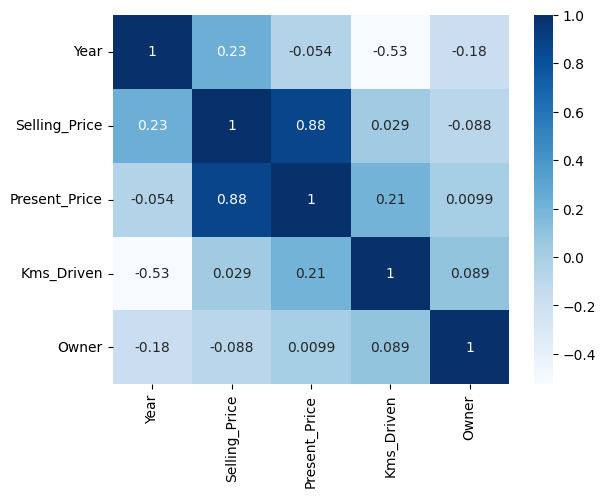

In [27]:
sns.heatmap(num_df.corr(),annot=True,cmap="Blues")

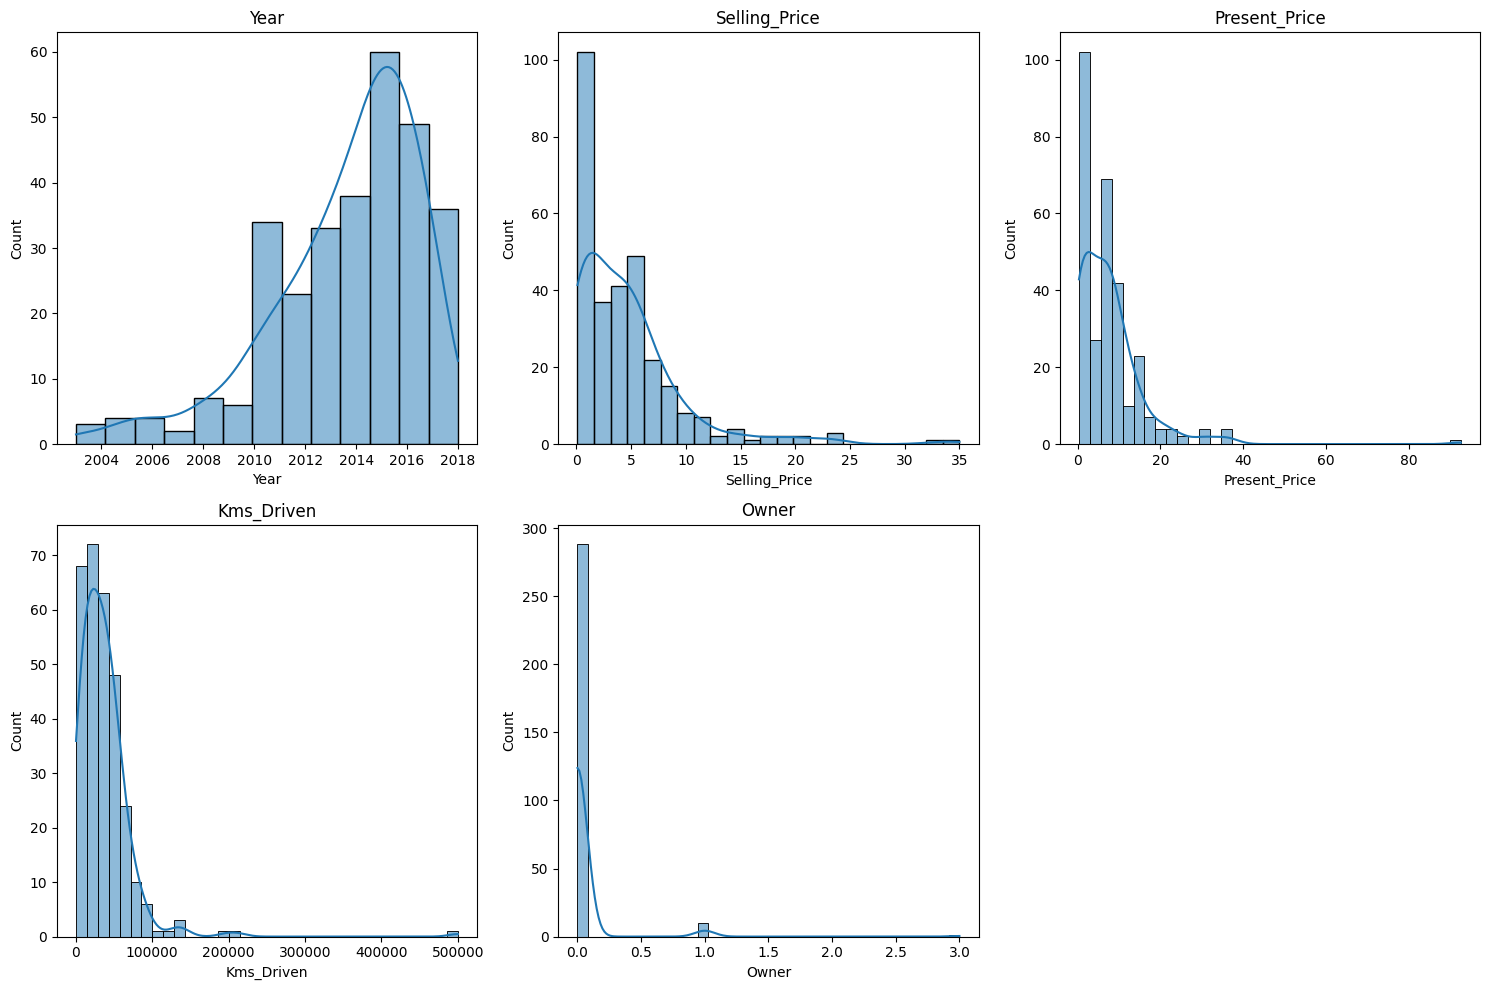

In [29]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

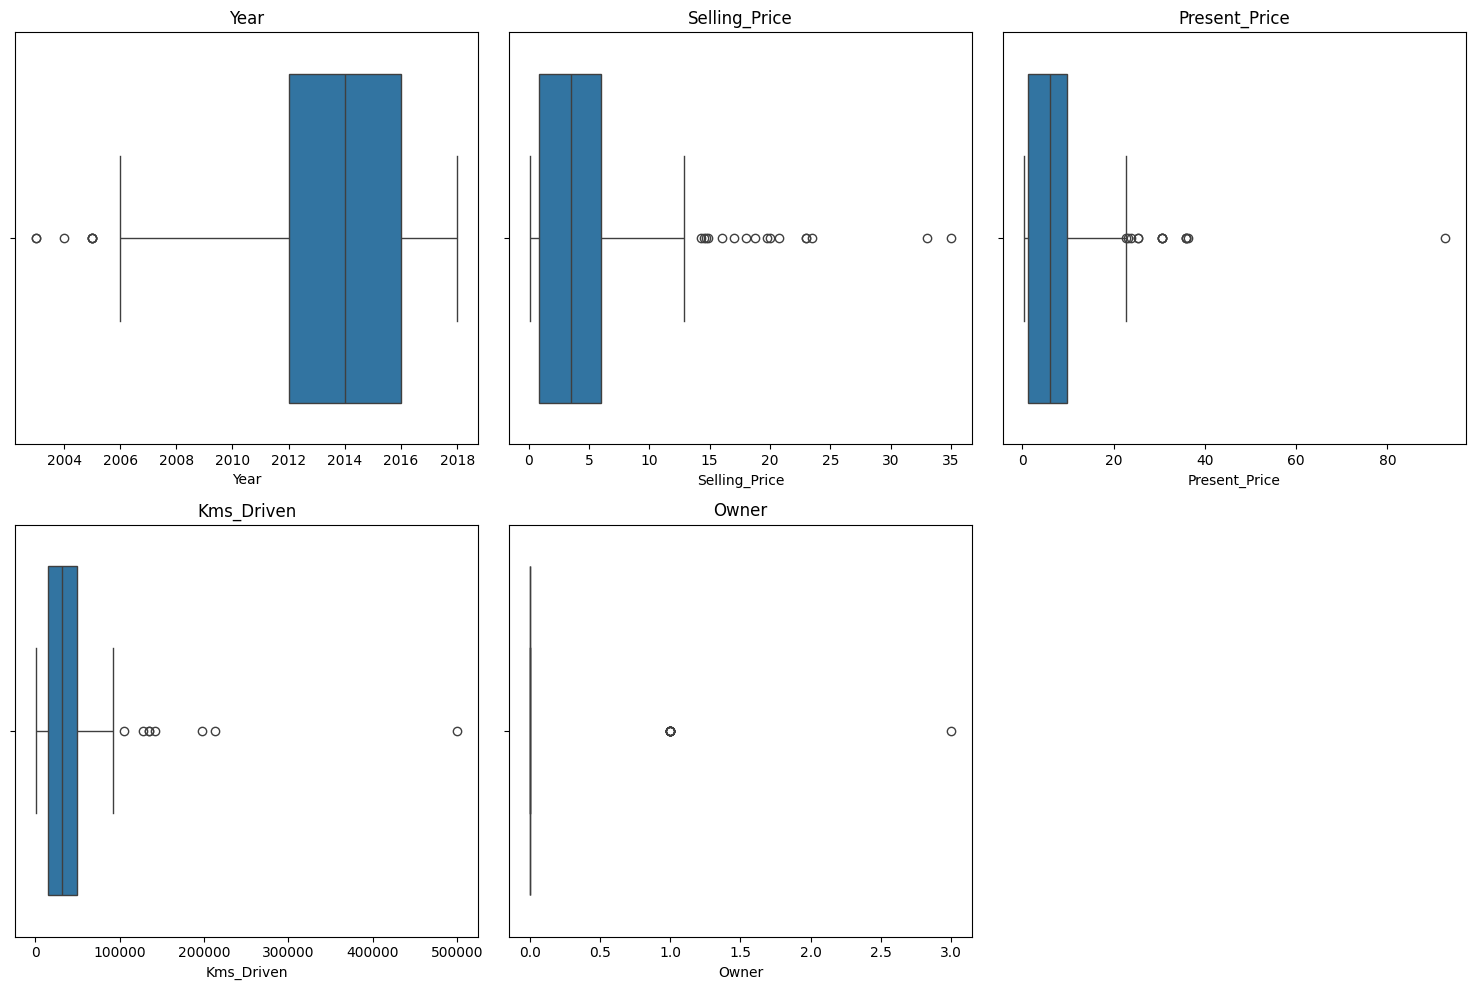

In [30]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

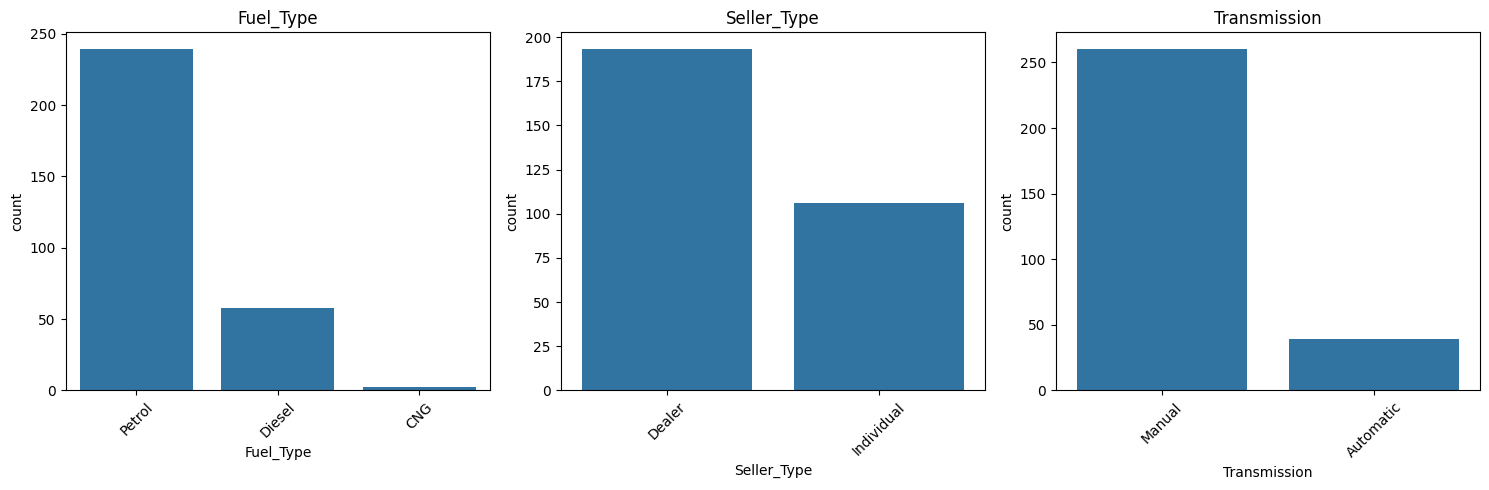

In [31]:
cols = cat_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=cat_df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [36]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)

In [40]:
num_df["Kms_Driven"]=np.log1p(num_df["Kms_Driven"])  

In [38]:
le = LabelEncoder()
for col in cat_df.columns:
    cat_df[col] = le.fit_transform(cat_df[col])

In [42]:
df = pd.concat([num_df,cat_df],axis=1)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type,Seller_Type,Transmission
0,2014,3.35,5.59,10.203629,0,2,0,1
1,2013,4.75,9.54,10.668979,0,1,0,1
2,2017,7.25,9.85,8.839422,0,2,0,1
3,2011,2.85,4.15,8.556606,0,2,0,1
4,2014,4.60,6.87,10.656106,0,1,0,1


In [44]:
X = df.drop("Selling_Price",axis=1)
y = df["Selling_Price"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
models = {
    "LinearRegression": (
        LinearRegression(),
        {}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [50,100,150,200],
         "max_depth": [5,10,20],
         "min_samples_split":[2,5,10,15]}
    ),
     "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {"n_estimators": [50,100,150,200],
         "learning_rate": [0.01,0.05,0.1],
         "max_depth": [3,5,7]}
    )
}

In [70]:
results = []

for name, (model, params) in models.items():

    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_


    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)


    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append([
        name,
        train_r2,
        test_r2,
        train_rmse,
        test_rmse,
        grid.best_params_
    ])


In [72]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "Train RMSE",
        "Test RMSE",
        "Best Params"
    ]
)

results_df.sort_values(by="Test R2", ascending=False)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Best Params
2,GradientBoosting,0.995622,0.703549,0.246687,2.009667,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
0,LinearRegression,0.910545,0.697648,1.115064,2.029571,{}
1,RandomForest,0.994733,0.664398,0.270559,2.138259,"{'max_depth': 20, 'min_samples_split': 2, 'n_e..."
